# Modello ARIMA applicato a serie temporale di dati rilevati da sensori


## Setup


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from util import (
    load_building_df,
    plot_dataframe,
    show_overview_for_value,
)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%reload_ext autoreload
%autoreload 2

Il notebook usa come esempio i dati dei consumi energetici dell'edificio 14.


(0.0, 637.875)

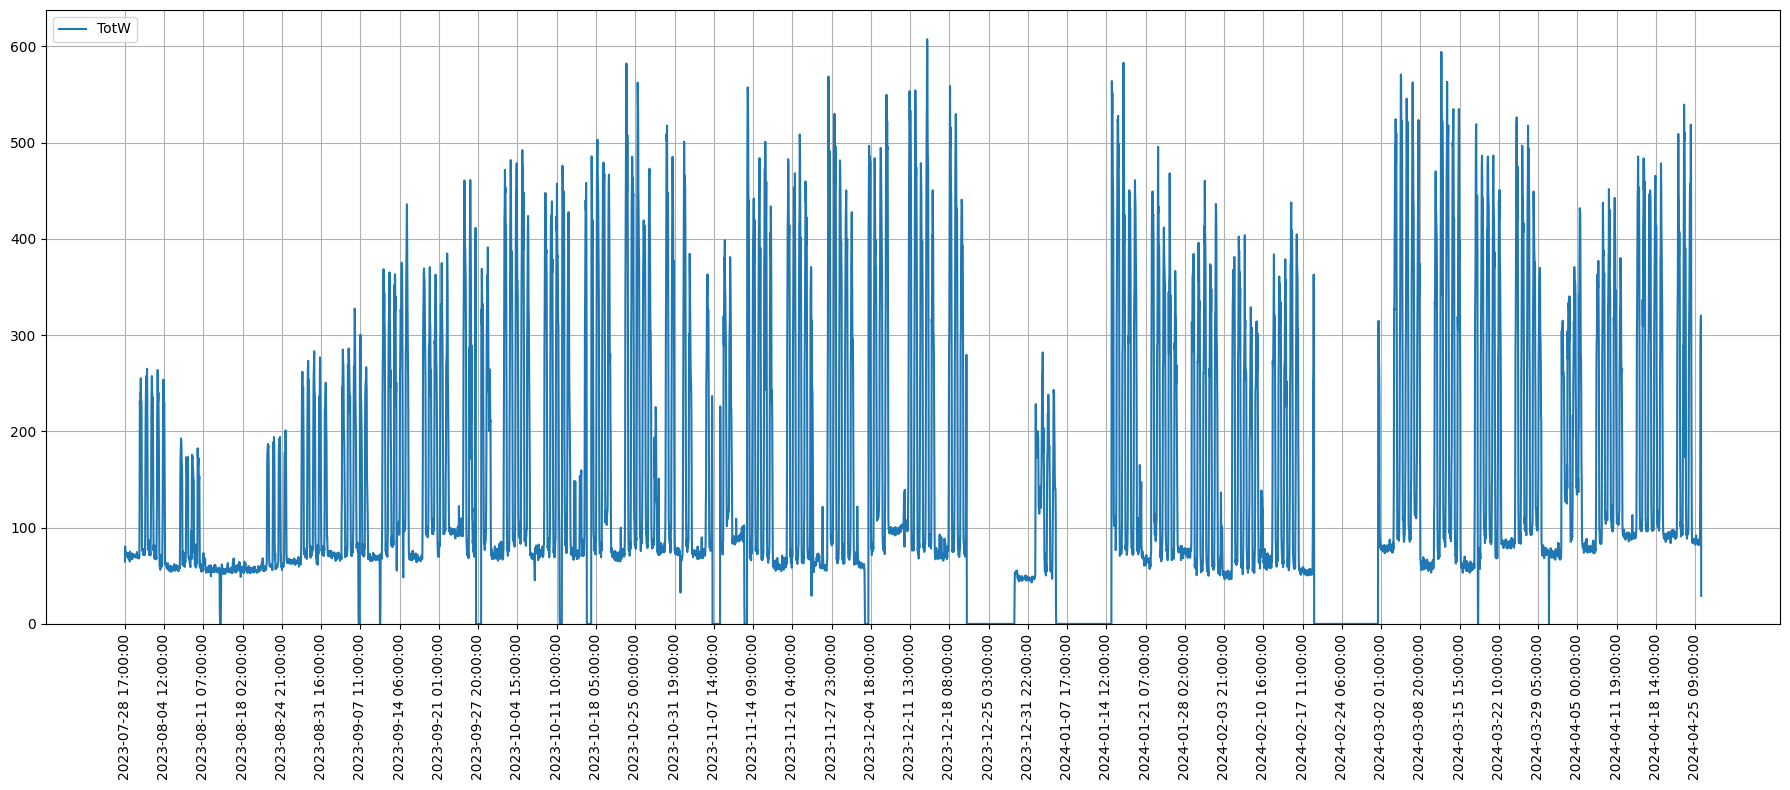

In [2]:
df = load_building_df(
    "TotW",
    "ED14_20240426.csv",
    "PM5320",
    "ARCH_FM",
    resample="h",
)


plot_dataframe(df, ["TotW"])
plt.ylim(0)

<Axes: xlabel='datetime'>

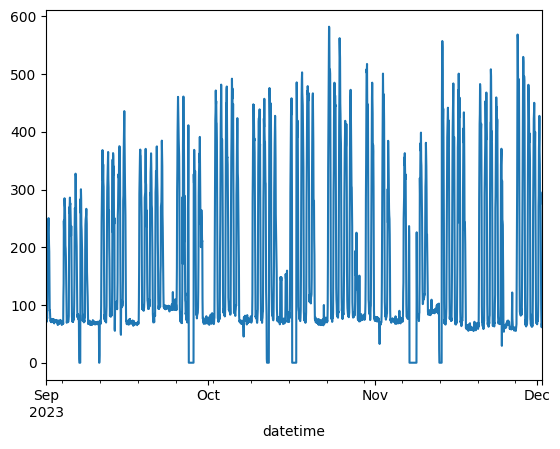

In [3]:
df.loc["2023-09-01":"2023-12-01"]["TotW"].plot()

In [4]:
show_overview_for_value(df, "TotW")

## Studio della stationarity

Una serie temporale è detta **stazionaria** se le sue proprietà statistiche (come media e varianza) rimangono costanti nel tempo. Il modello ARIMA può essere utilizzato sia per serie stazionarie che non, ma nel secondo caso sarà necessario determinare il parametro `d` del modello, ossia il grado di differencing da applicare alla serie temporale.

È possibile fare uso di diverse tecniche per determinare se una serie temporale è stazionaria o meno, mostrati nei paragrafi successivi:

- studio di media e varianza nel tempo;
- Test ADF;
- Test KPSS.


### Via grafo della media e della varianza

Un'iniziale ispezione dei grafi di media e varianza dei consumi energetici (TotW), generati usando rolling window di diverse dimensioni, mostra che media e varianza cambiano molto frequentemente: questo dà un'indicazione di non-stazionarità.


<Axes: >

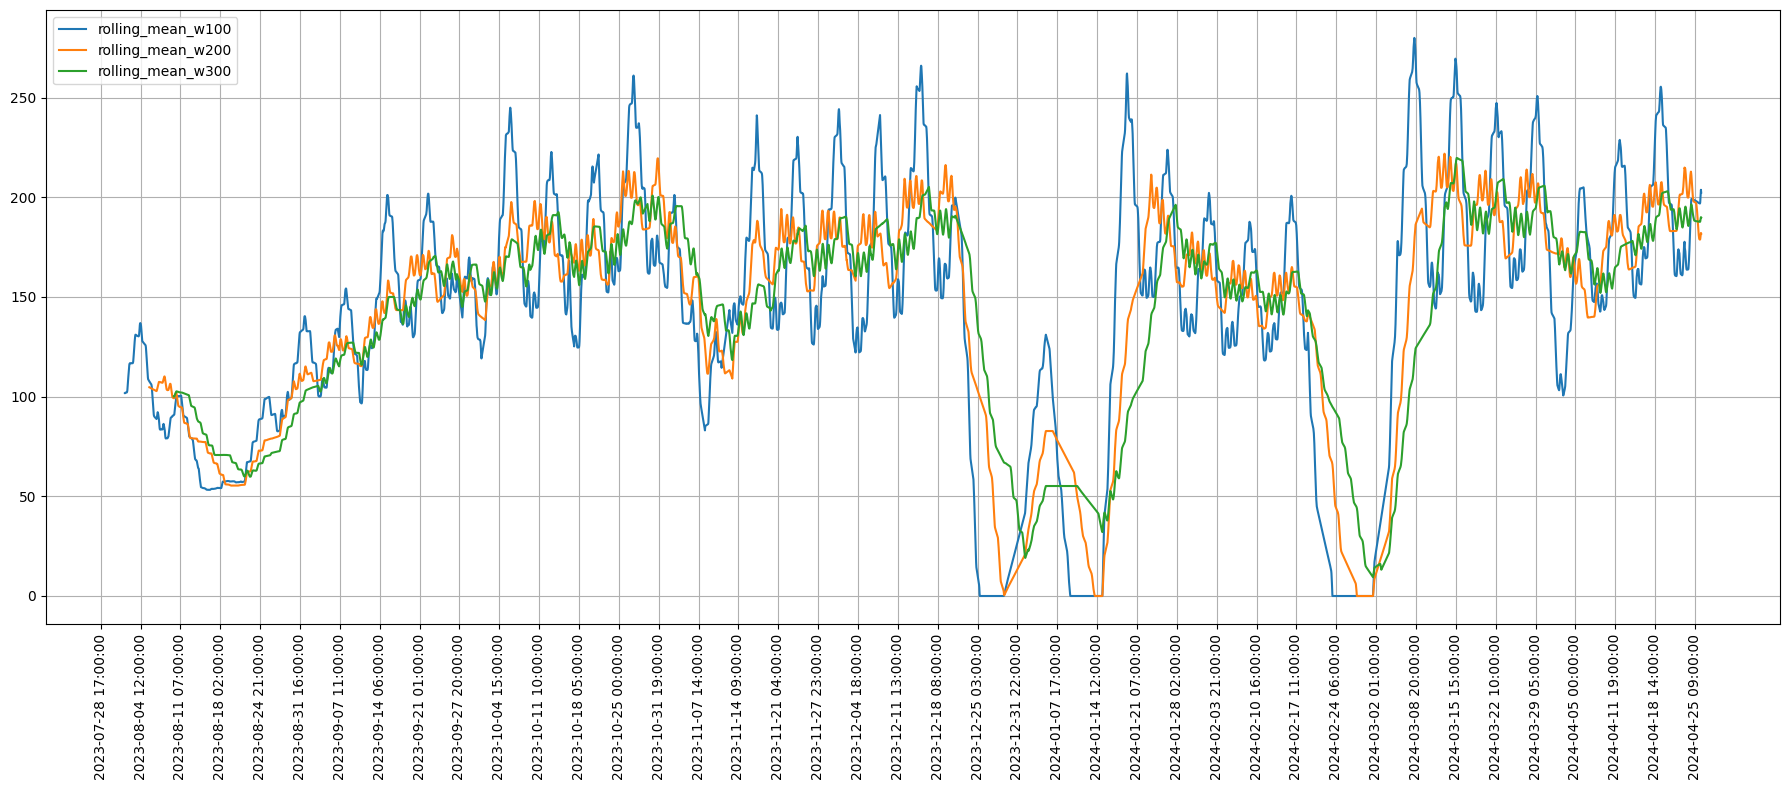

In [5]:
df["rolling_mean_w100"] = df["TotW"].rolling(window=100).mean()
df["rolling_mean_w200"] = df["TotW"].rolling(window=200).mean()
df["rolling_mean_w300"] = df["TotW"].rolling(window=300).mean()

plot_dataframe(
    df,
    [
        "rolling_mean_w100",
        "rolling_mean_w200",
        "rolling_mean_w300",
    ],
)

<Axes: >

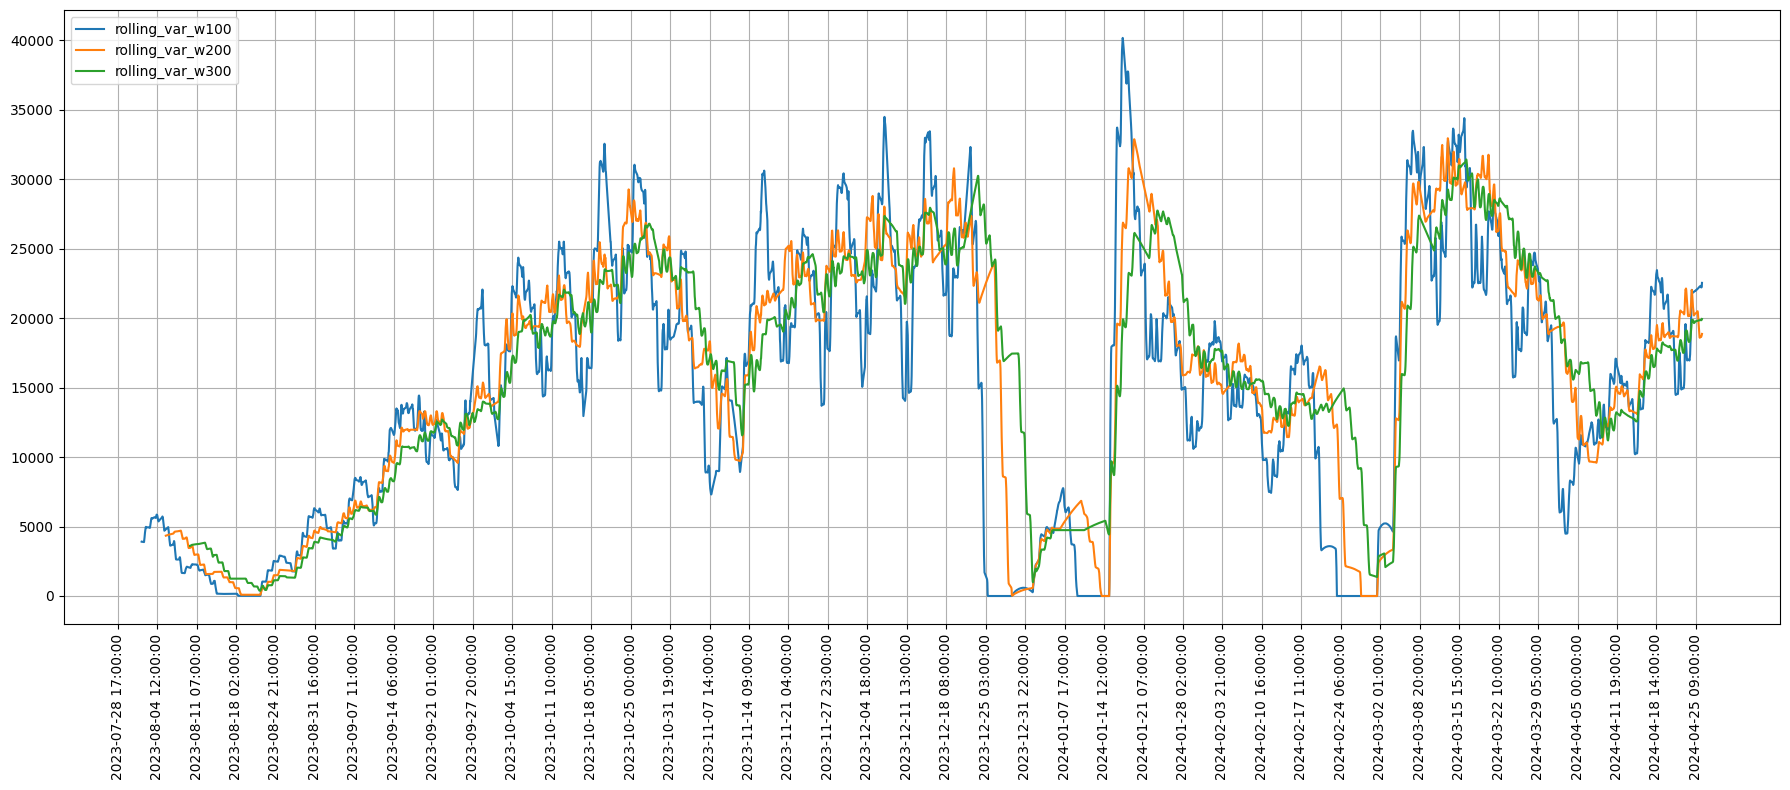

In [6]:
df["rolling_var_w300"] = df["TotW"].rolling(window=300).var()
df["rolling_var_w200"] = df["TotW"].rolling(window=200).var()
df["rolling_var_w100"] = df["TotW"].rolling(window=100).var()

plot_dataframe(
    df,
    [
        "rolling_var_w100",
        "rolling_var_w200",
        "rolling_var_w300",
    ],
)

### Via test Augmented Dickey-Fuller

Il test Augmented Dickey-Fuller considera due ipotesi:

- Ipotesi nulla $H_0$: la serie temporale non è stazionaria;
- Ipotesi alternative $H_1$: la serie temporale è stazionaria.

Per rifiutare l'ipotesi nulla, si setta una soglia (tipicamente dello 0.05): se il p-value restituito dal test ADF è inferiore a questa soglia, l'ipotesi nulla è rifiutata, indicando che plausibilmente la serie temporale è stazionaria.


In [7]:
from statsmodels.tsa.stattools import adfuller

adf_res = adfuller(df["TotW"])
adf_stat = adf_res[0]
adf_pvalue = adf_res[1]

print(f"ADF Statistic: {adf_stat}")
print(f"p-value:       {adf_pvalue}")

ADF Statistic: -8.379012436352996
p-value:       2.539873829361464e-13


Il p-value è molto inferiore alla soglia dello 0.05, quindi l'ipotesi nulla è rifiutata e la serie è stazionaria secondo questo test.


### Via test KPSS

Il test KPSS considera due ipotesi, opposte a quelle del test ADF:

- Ipotesi nulla $H_0$: la serie temporale _è stazionaria_;
- Ipotesi alternativa $H_1$: la serie temporale è non-stazionaria.

Per rifiutare l'ipotesi nulla si procede come per il test ADF: si setta una soglia (0.05), che sarà confrontata col p-value.


In [8]:
from statsmodels.tsa.stattools import kpss

kpss_res = kpss(df["TotW"])
kpss_stat = kpss_res[0]
kpss_pvalue = kpss_res[1]

print(f"KPSS Statistic: {kpss_stat}")
print(f"p-value:       {kpss_pvalue}")

KPSS Statistic: 0.48174218030653315
p-value:       0.04577878821924929


### Risultato

In sintesi, per il dataset inerente all'edificio 14:

- un'ispezione grafica rivela non-stazionarità;
- i risultati del test ADF indicano stazionarità;
- i risultati del test KPSS indicano non-stazionarità.

I risultati sono contrastanti: i grafici di media e varianza mostrano alta variabilità (e quindi non-stazionarità), mentre il test ADF e il test KPSS mostrano risultati opposti.


## Approccio #1: studio e rimozione della seasonality e AutoARIMA


### De-trending

Il de-trending consiste nell'atto di rimuovere il trend da una timeseries.

Ho provato due strategie per raggiungere questo obiettivo:

- calcolare la rolling average della serie, e sottrarla alla serie originale;
- utilizzare il metodo `seasonal_decompose` della libreria `statsmodels.tsa.seasonal` e sottrarre il trend individuato


In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df["TotW"], model="additive", period=30)
df["TotW_deseasonalized"] = df["TotW"] - result.seasonal

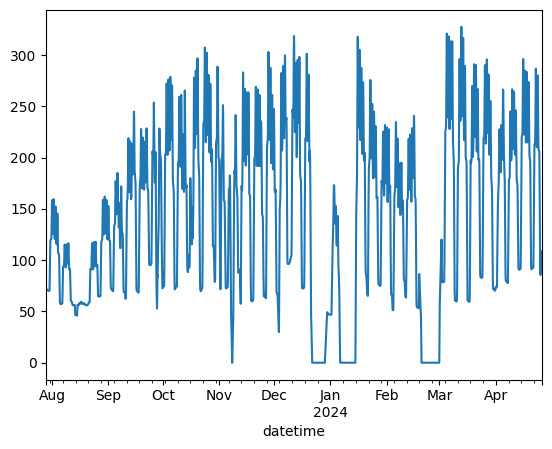

In [10]:
fig = result.trend.plot()

<Axes: xlabel='datetime'>

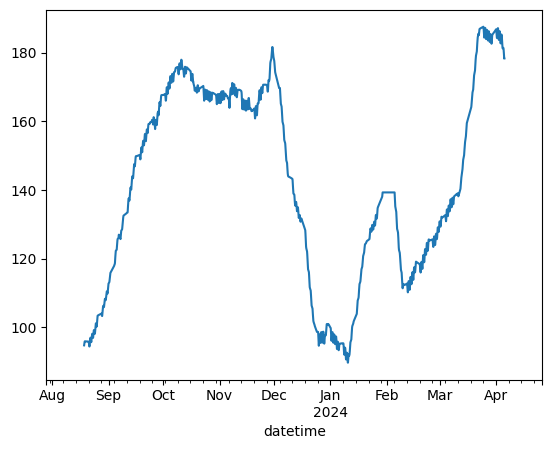

In [11]:
df["trend"] = df["TotW"].rolling(window=1000, center=True).mean()

df["trend"].plot()

<Axes: xlabel='datetime'>

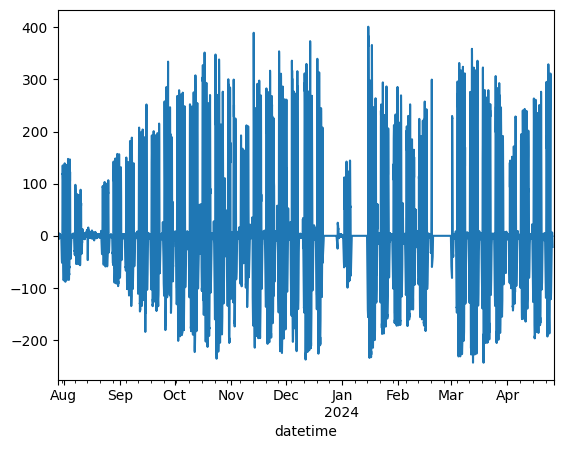

In [12]:
df["detrended"] = df["TotW"] - result.trend
df["detrended"].plot()

### Grafico post-detrending


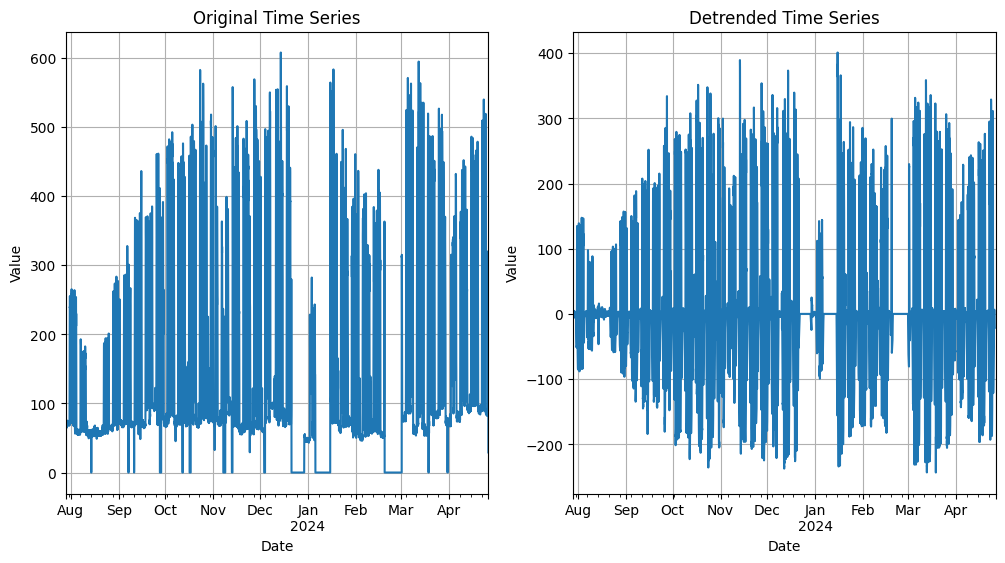

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the original time series on the first subplot
df["TotW"].plot(ax=axes[0], title="Original Time Series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Value")
axes[0].grid(True)

# Plot the deseasonalized time series on the second subplot
df["detrended"].plot(ax=axes[1], title="Detrended Time Series")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value")
axes[1].grid(True)

### Predizioni sulla serie detrended


In [14]:
from pmdarima import auto_arima

model = auto_arima(df["detrended"][df["detrended"] >= 0].dropna())

/home/impasse/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/impasse/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


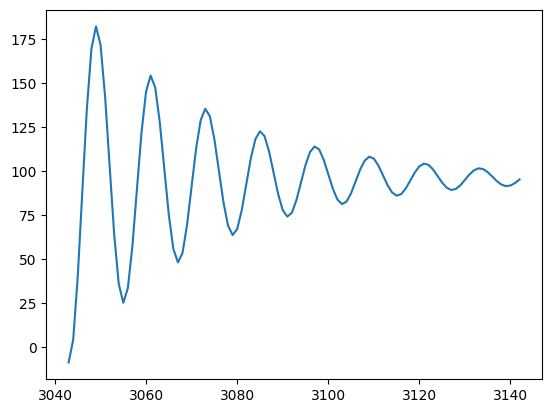

In [15]:
predictions = model.predict(n_periods=100)

plt.plot(predictions, label="forecast")

## Approccio #2: differencing


In [16]:
# reset the dataframe
diff_df = load_building_df(
    "TotW",
    "ED14_20240426.csv",
    "PM5320",
    "ARCH_FM",
    resample="h",
)

### Ordine del termine di differenziazione (d)

Il termine di differenziazione va identificato allo scopo di rimuovere la non-stazionarità da una serie temporale. Alla serie in questione verranno infatti sottratti i `d` lag precedenti allo scopo di ridurre la variazione di media e varianza nel plot.

In questo esempio, identifico il parametro in questione tramite un'ispezione visiva: decido che differenziare usando i primi 2 lag riduce sufficientemente la non-stazionarità.


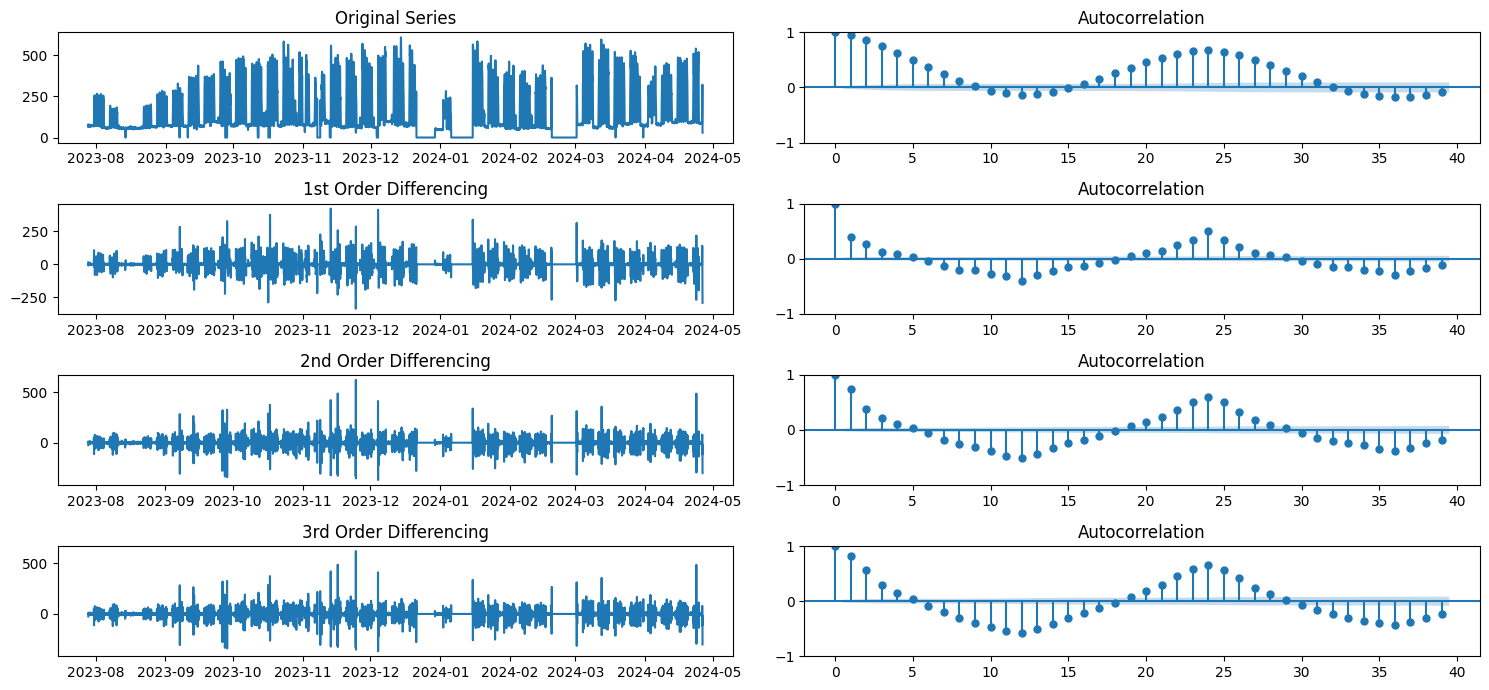

In [17]:
# Original Series
fig, axes = plt.subplots(4, 2, figsize=(15, 7))
axes[0, 0].plot(diff_df["TotW"])
axes[0, 0].set_title("Original Series")
plot_acf(diff_df["TotW"], ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(diff_df["TotW"].diff())
axes[1, 0].set_title("1st Order Differencing")
plot_acf(diff_df["TotW"].diff(periods=1).dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(diff_df["TotW"].diff().diff())
axes[2, 0].set_title("2nd Order Differencing")
plot_acf(diff_df["TotW"].diff(periods=2).dropna(), ax=axes[2, 1])


axes[3, 0].plot(diff_df["TotW"].diff().diff())
axes[3, 0].set_title("3rd Order Differencing")
plot_acf(diff_df["TotW"].diff(periods=3).dropna(), ax=axes[3, 1])

plt.tight_layout()
plt.show()

In [18]:
df["TotW"] = df["TotW"].diff(periods=2)
df = df.dropna()

In [19]:
from statsmodels.tsa.stattools import adfuller

adf_res = adfuller(df["TotW"])
adf_stat = adf_res[0]
adf_pvalue = adf_res[1]

print(f"ADF Statistic: {adf_stat}")
print(f"p-value:       {adf_pvalue}")

ADF Statistic: -15.328789757847435
p-value:       3.9717987279267107e-28


In [20]:
from statsmodels.tsa.stattools import kpss

kpss_res = kpss(df["TotW"])
kpss_stat = kpss_res[0]
kpss_pvalue = kpss_res[1]

print(f"KPSS Statistic: {kpss_stat}")
print(f"p-value:       {kpss_pvalue}")

KPSS Statistic: 0.008525450882796558
p-value:       0.1


/tmp/ipykernel_249421/48609143.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(df["TotW"])


### Ordine del termine AR (p)

Il termine AR può essere identificato ispezionando il grafico della funzione PACF e selezionando il lag con la correlazione più significativa (in questo caso, il primo, per cui: `p = 1`).


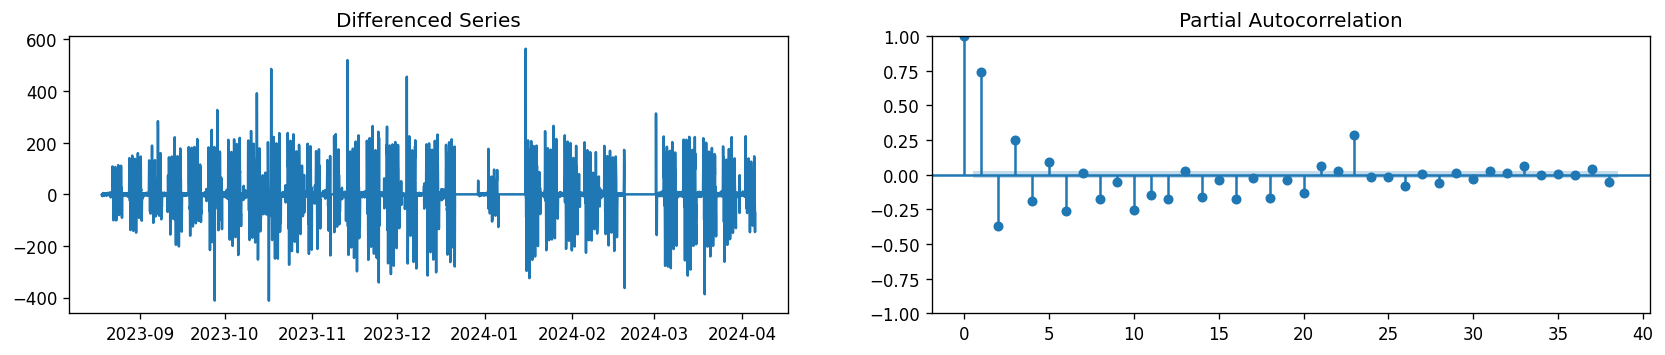

In [21]:
# PACF plot of 1st differenced series
plt.rcParams.update({"figure.figsize": (17, 3), "figure.dpi": 120})

fig, axes = plt.subplots(1, 2)

axes[0].plot(df["TotW"])
axes[0].set_title("Differenced Series")

plot_pacf(df["TotW"], ax=axes[1])

plt.show()

### Ordine del termine MA (q)


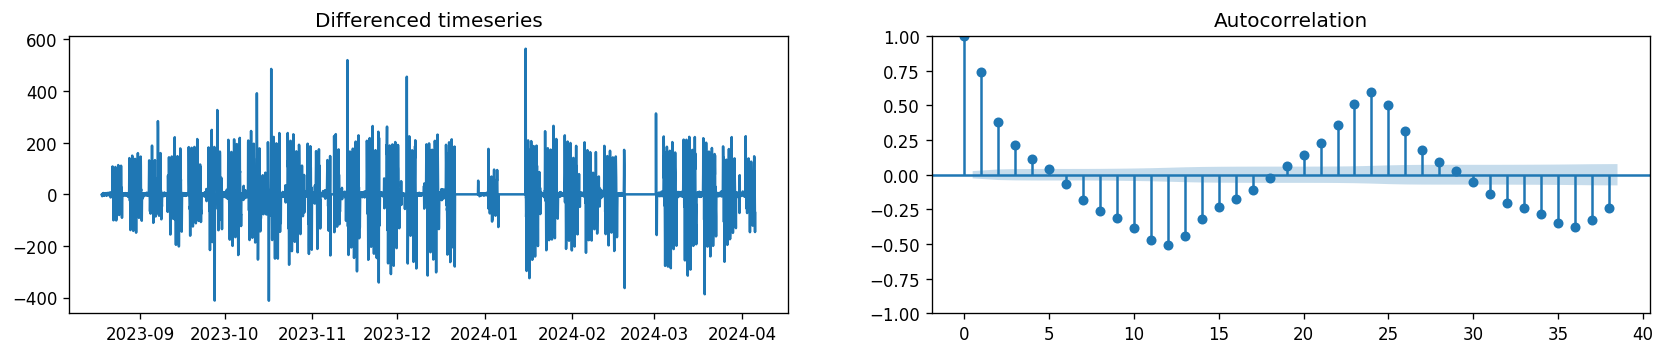

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({"figure.figsize": (17, 3), "figure.dpi": 120})

fig, axes = plt.subplots(1, 2)

axes[0].plot(df["TotW"])
axes[0].set_title("Differenced timeseries")
axes[1].set(ylim=(0, 1.2))

plot_acf(df["TotW"], ax=axes[1])

plt.show()

In [23]:
from statsmodels.tsa.arima.model import ARIMA

diff_model = ARIMA(df["TotW"], order=(1, 2, 1))
model_fit = diff_model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   TotW   No. Observations:                 5547
Model:                 ARIMA(1, 2, 1)   Log Likelihood              -29665.195
Date:                Fri, 31 May 2024   AIC                          59336.391
Time:                        18:41:41   BIC                          59356.253
Sample:                    08-18-2023   HQIC                         59343.316
                         - 04-05-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1952      0.008     23.994      0.000       0.179       0.211
ma.L1         -1.0000      0.330     -3.030      0.002      -1.647      -0.353
sigma2      2592.6862    854.005      3.036      0.0

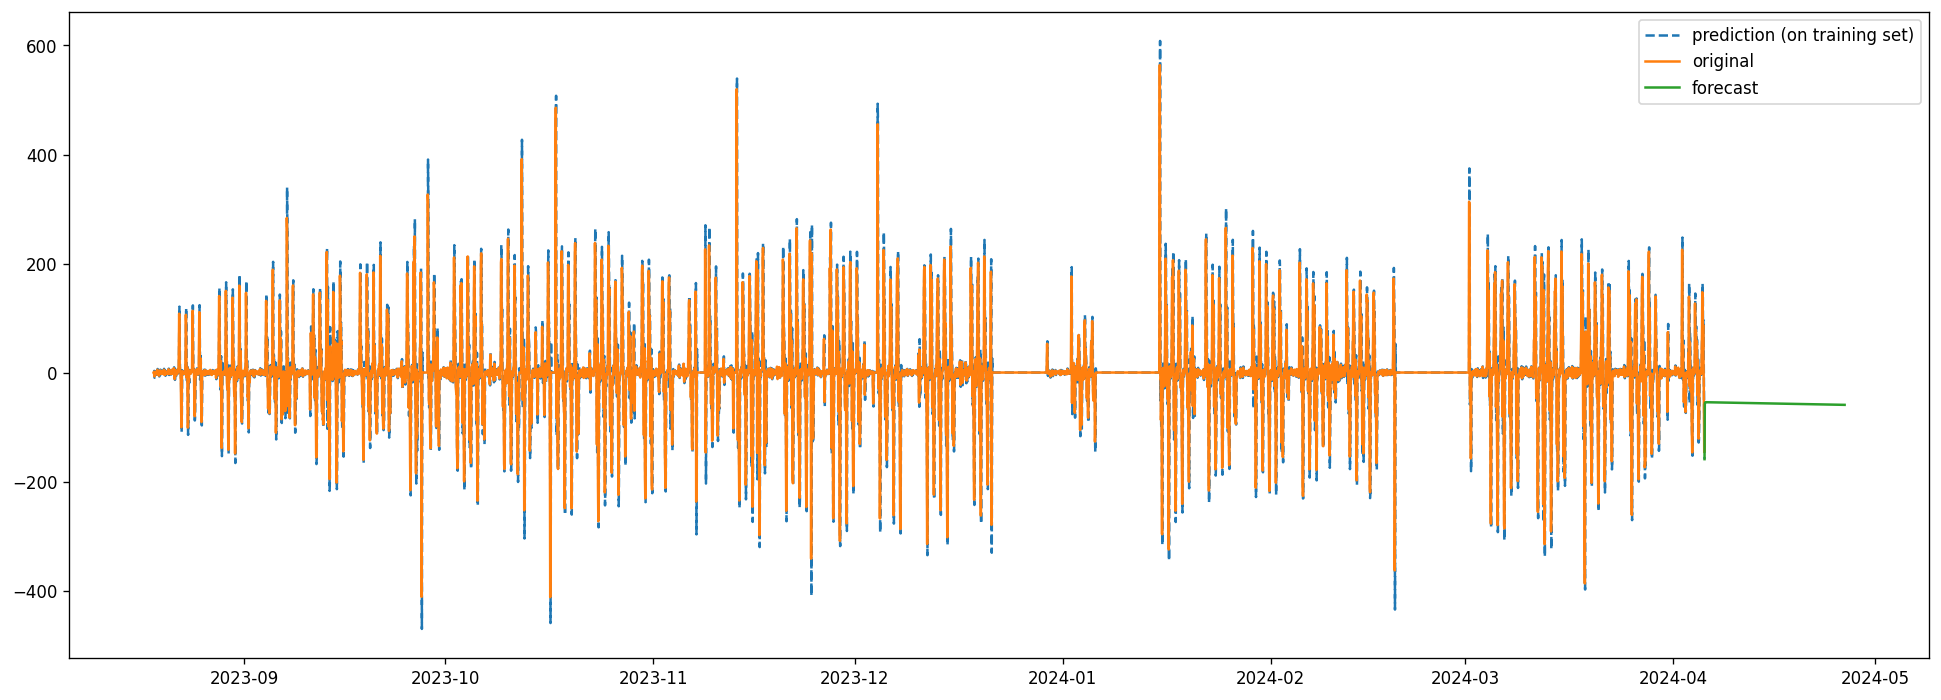

In [24]:
predictions = model_fit.predict(df.shape[0] - 1, df.shape[0] + 500)

plt.figure(figsize=(20, 7))
plt.plot(model_fit.predict(), "--", label="prediction (on training set)")
plt.plot(df["TotW"], label="original")
plt.plot(predictions, label="forecast")
plt.legend()

In [25]:
df

,TotW,hour,dayofweek,week,rolling_mean_w100,rolling_mean_w200,rolling_mean_w300,rolling_var_w300,rolling_var_w200,rolling_var_w100,TotW_deseasonalized,trend,detrended
datetime,,,,,,,,,,,,,
2023-08-18 13:00:00,-0.07,13,4,32,57.4146,60.70970,70.764667,1248.014218,560.520126,13.774674,63.000165,94.75615,5.262500
2023-08-18 14:00:00,1.48,14,4,32,57.4480,60.61995,70.772367,1247.866601,558.593401,13.995228,65.041282,94.94428,4.712333
2023-08-18 15:00:00,-5.82,15,4,32,57.4040,59.99325,70.770833,1247.908022,483.712639,13.830428,54.363119,95.11988,-0.623667
2023-08-18 16:00:00,-7.11,16,4,32,57.3380,59.40835,70.764967,1248.080230,420.168163,13.671895,48.628311,95.31560,-2.426333
2023-08-18 17:00:00,-1.13,17,4,32,57.3052,58.86140,70.764900,1248.082210,363.538086,13.654110,54.073329,95.49525,-1.671667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-05 11:00:00,43.07,11,4,13,190.6298,165.26655,178.321867,16594.573580,12462.179465,11085.850305,425.538359,178.60855,227.158833
2024-04-05 12:00:00,-5.72,12,4,13,194.1431,166.89365,179.457833,16769.835723,12780.665566,11498.351117,429.743010,178.49752,227.357333
2024-04-05 13:00:00,-79.76,13,4,13,196.8713,168.12305,180.336667,16834.412778,12923.724851,11588.865628,350.328510,178.46353,151.657667
